# EDA 10.2: Return Reason Analysis

This notebook analyzes return reasons, how they differ by category and size, whether wrong-size returns concentrate in specific groups, how reason mix changes over time, and which historical reason aggregates may be useful for explainability or forecasting.

## 1. Setup and File Discovery

Locate required and optional CSV files anywhere under the current working directory. Missing files produce warnings and the notebook continues where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 220)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['returns.csv', 'order_items.csv', 'products.csv', 'orders.csv', 'sales.csv']

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in ['returns.csv', 'order_items.csv', 'products.csv'], 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in ['returns.csv', 'order_items.csv', 'products.csv']:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,returns.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\re...
1,order_items.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
2,products.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
3,orders.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
4,sales.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...


## 2. Load Returns, Order Items, Products, and Optional Files

Load all available CSVs safely with pandas and display the raw schemas.

In [2]:
def safe_read_csv(path, name):
    if path is None:
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns from {path}')
        return df
    except Exception as exc:
        warnings.warn(f'Could not load {name} from {path}: {exc}')
        return None

raw = {name: safe_read_csv(path, name) for name, path in selected_paths.items()}
returns_raw = raw.get('returns.csv')
order_items_raw = raw.get('order_items.csv')
products_raw = raw.get('products.csv')
orders_raw = raw.get('orders.csv')
sales_raw = raw.get('sales.csv')

schema_rows = []
for name, df in raw.items():
    if df is not None:
        schema_rows.append({'file': name, 'rows': len(df), 'columns': len(df.columns), 'column_names': ', '.join(map(str, df.columns))})
schema_overview = pd.DataFrame(schema_rows)
display(schema_overview)

Loaded returns.csv: 39,939 rows x 7 columns from D:\Code\Datathon 2026\datathon-2026-round-1\returns.csv


Loaded order_items.csv: 714,669 rows x 7 columns from D:\Code\Datathon 2026\datathon-2026-round-1\order_items.csv
Loaded products.csv: 2,412 rows x 8 columns from D:\Code\Datathon 2026\datathon-2026-round-1\products.csv


Loaded orders.csv: 646,945 rows x 8 columns from D:\Code\Datathon 2026\datathon-2026-round-1\orders.csv
Loaded sales.csv: 3,833 rows x 3 columns from D:\Code\Datathon 2026\datathon-2026-round-1\sales.csv


,file,rows,columns,column_names
0,returns.csv,39939,7,"return_id, order_id, product_id, return_date, ..."
1,order_items.csv,714669,7,"order_id, product_id, quantity, unit_price, di..."
2,products.csv,2412,8,"product_id, product_name, category, segment, s..."
3,orders.csv,646945,8,"order_id, order_date, customer_id, zip, order_..."
4,sales.csv,3833,3,"Date, Revenue, COGS"


## 3. Identify Return Reason, Key, Product, Category, Size, Date, Quantity, and Refund Columns

Column matching normalizes case, spaces, punctuation, and underscores, then uses candidate names and keyword scoring for minor naming differences.

In [3]:
def column_lookup(df):
    if df is None:
        return {}
    return {normalize_name(c): c for c in df.columns}

def find_col(df, candidates=None, include_all=None, include_any=None, exclude_any=None, prefer_numeric=False):
    if df is None:
        return None
    candidates = candidates or []
    include_all = [normalize_name(x) for x in (include_all or [])]
    include_any = [normalize_name(x) for x in (include_any or [])]
    exclude_any = [normalize_name(x) for x in (exclude_any or [])]
    lookup = column_lookup(df)
    for cand in candidates:
        key = normalize_name(cand)
        if key in lookup:
            return lookup[key]
    scored = []
    for col in df.columns:
        key = normalize_name(col)
        if exclude_any and any(x in key for x in exclude_any):
            continue
        if include_all and not all(x in key for x in include_all):
            continue
        if include_any and not any(x in key for x in include_any):
            continue
        score = sum(3 for x in include_all if x in key) + sum(2 for x in include_any if x in key)
        if prefer_numeric and pd.api.types.is_numeric_dtype(df[col]):
            score += 1
        scored.append((score, len(key), col))
    if scored:
        scored.sort(key=lambda x: (-x[0], x[1], str(x[2])))
        return scored[0][2]
    return None

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

cols = {}
if returns_raw is not None:
    cols['return_id'] = find_col(returns_raw, ['return_id', 'returnid', 'rma_id'], include_any=['returnid', 'rmaid'])
    cols['ret_order_id'] = find_col(returns_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['ret_product_id'] = find_col(returns_raw, ['product_id', 'productid', 'sku_id'], include_any=['productid', 'skuid'])
    cols['ret_customer_id'] = find_col(returns_raw, ['customer_id', 'customerid'], include_all=['customer', 'id'])
    cols['return_date'] = find_col(returns_raw, ['return_date', 'date', 'refund_date'], include_any=['returndate', 'refunddate', 'date'])
    cols['return_reason'] = find_col(returns_raw, ['return_reason', 'reason', 'reason_code', 'return_category'], include_any=['returnreason', 'reasoncode', 'reason', 'returncategory'])
    cols['return_qty'] = find_col(returns_raw, ['return_quantity', 'returned_quantity', 'quantity_returned', 'quantity', 'qty'], include_any=['returnquantity', 'returnedquantity', 'quantityreturned', 'quantity', 'qty'], prefer_numeric=True)
    cols['refund_amount'] = find_col(returns_raw, ['refund_amount', 'refund_value', 'refund', 'amount'], include_any=['refundamount', 'refundvalue', 'refund'], exclude_any=['id'], prefer_numeric=True)
if order_items_raw is not None:
    cols['oi_order_id'] = find_col(order_items_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['oi_product_id'] = find_col(order_items_raw, ['product_id', 'productid', 'sku_id'], include_any=['productid', 'skuid'])
    cols['oi_qty'] = find_col(order_items_raw, ['quantity', 'qty', 'units_sold'], include_any=['quantity', 'qty', 'unitssold'], prefer_numeric=True)
    cols['oi_unit_price'] = find_col(order_items_raw, ['unit_price', 'selling_price', 'price'], include_any=['unitprice', 'sellingprice', 'price'], exclude_any=['discount', 'cost'], prefer_numeric=True)
    cols['oi_discount'] = find_col(order_items_raw, ['discount_amount', 'discount_value', 'discount'], include_any=['discountamount', 'discountvalue', 'discount'], exclude_any=['id'], prefer_numeric=True)
    cols['oi_date'] = find_col(order_items_raw, ['order_date', 'date', 'item_date'], include_any=['date'])
if products_raw is not None:
    cols['prod_product_id'] = find_col(products_raw, ['product_id', 'productid', 'sku_id'], include_any=['productid', 'skuid'])
    cols['prod_category'] = find_col(products_raw, ['category', 'product_category'], include_any=['category'])
    cols['prod_size'] = find_col(products_raw, ['size', 'product_size'], include_any=['size'])
    cols['prod_segment'] = find_col(products_raw, ['segment', 'product_segment'], include_any=['segment'])
if orders_raw is not None:
    cols['orders_order_id'] = find_col(orders_raw, ['order_id', 'orderid'], include_all=['order', 'id'])
    cols['orders_date'] = find_col(orders_raw, ['order_date', 'date'], include_any=['orderdate', 'date'])

identified_columns = pd.DataFrame([{'role': k, 'column': v} for k, v in cols.items()])
display(identified_columns)

,role,column
0,return_id,return_id
1,ret_order_id,order_id
2,ret_product_id,product_id
3,ret_customer_id,None
4,return_date,return_date
5,return_reason,return_reason
6,return_qty,return_quantity
7,refund_amount,refund_amount
8,oi_order_id,order_id
9,oi_product_id,product_id


## 4. Return Reason Data Quality Checks

Standardize return-reason labels, inspect missing keys and dates, and display return reason counts.

In [4]:
returns_df = pd.DataFrame()
reason_warnings = []

def normalize_reason_label(x):
    if pd.isna(x) or str(x).strip() == '':
        return 'unknown'
    s = str(x).strip().lower()
    s = re.sub(r'[\s\-]+', '_', s)
    s = re.sub(r'[^a-z0-9_]+', '', s)
    replacements = {
        'wrongsize': 'wrong_size',
        'sizeissue': 'wrong_size',
        'toosmall': 'too_small',
        'toolarge': 'too_large',
        'fitissue': 'fit_issue',
        'notasdescribed': 'not_as_described',
        'qualityissue': 'quality_issue',
        'latedelivery': 'late_delivery',
        'wrongitem': 'wrong_item',
    }
    return replacements.get(s, s)

if returns_raw is None or returns_raw.empty:
    reason_warnings.append('returns.csv is missing or empty.')
else:
    returns_df = returns_raw.copy()
    returns_df['return_id_std'] = returns_df[cols['return_id']].astype('string').str.strip() if cols.get('return_id') else pd.NA
    returns_df['order_id_std'] = returns_df[cols['ret_order_id']].astype('string').str.strip() if cols.get('ret_order_id') else pd.NA
    returns_df['product_id_std'] = returns_df[cols['ret_product_id']].astype('string').str.strip() if cols.get('ret_product_id') else pd.NA
    returns_df['return_date_std'] = pd.to_datetime(returns_df[cols['return_date']], errors='coerce').dt.floor('D') if cols.get('return_date') else pd.NaT
    if cols.get('return_reason'):
        returns_df['return_reason_std'] = returns_df[cols['return_reason']].map(normalize_reason_label)
    else:
        returns_df['return_reason_std'] = 'unknown'
        reason_warnings.append('Return reason column could not be identified.')
    returns_df['returned_quantity_std'] = to_num(returns_df[cols['return_qty']]) if cols.get('return_qty') else np.nan
    returns_df['refund_amount_std'] = to_num(returns_df[cols['refund_amount']]) if cols.get('refund_amount') else np.nan
    report = pd.DataFrame([
        {'metric': 'return_rows', 'value': len(returns_df)},
        {'metric': 'return_date_range_start', 'value': returns_df['return_date_std'].min()},
        {'metric': 'return_date_range_end', 'value': returns_df['return_date_std'].max()},
        {'metric': 'missing_return_reasons', 'value': int((returns_df['return_reason_std'] == 'unknown').sum())},
        {'metric': 'unique_return_reasons', 'value': returns_df['return_reason_std'].nunique(dropna=True)},
        {'metric': 'missing_order_ids', 'value': int(returns_df['order_id_std'].isna().sum())},
        {'metric': 'missing_product_ids', 'value': int(returns_df['product_id_std'].isna().sum())},
        {'metric': 'missing_return_dates', 'value': int(pd.Series(returns_df['return_date_std']).isna().sum())},
        {'metric': 'duplicate_return_records', 'value': int(returns_df.duplicated(['order_id_std', 'product_id_std', 'return_date_std', 'return_reason_std']).sum())},
    ])
    display(report)
    display(returns_df['return_reason_std'].value_counts(dropna=False).rename_axis('return_reason').reset_index(name='count'))
    display(returns_df.head())

if reason_warnings:
    print('Return reason warnings:')
    for w in reason_warnings:
        print('-', w)

,metric,value
0,return_rows,39939
1,return_date_range_start,2012-07-11 00:00:00
2,return_date_range_end,2022-12-31 00:00:00
3,missing_return_reasons,0
4,unique_return_reasons,5
5,missing_order_ids,0
6,missing_product_ids,0
7,missing_return_dates,0
8,duplicate_return_records,0


,return_reason,count
0,wrong_size,13967
1,defective,8020
2,not_as_described,7035
3,changed_mind,6931
4,late_delivery,3986


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount,return_id_std,order_id_std,product_id_std,return_date_std,return_reason_std,returned_quantity_std,refund_amount_std
0,RET-000001,2,609,2012-07-25,late_delivery,6,"52,458.0100",RET-000001,2,609,2012-07-25,late_delivery,6,"52,458.0100"
1,RET-000002,32,1862,2012-07-16,wrong_size,2,"5,141.3700",RET-000002,32,1862,2012-07-16,wrong_size,2,"5,141.3700"
2,RET-000003,35,2359,2012-07-16,wrong_size,1,"5,315.9500",RET-000003,35,2359,2012-07-16,wrong_size,1,"5,315.9500"
3,RET-000004,47,1449,2012-07-11,wrong_size,4,"6,493.7500",RET-000004,47,1449,2012-07-11,wrong_size,4,"6,493.7500"
4,RET-000005,47,1450,2012-07-25,wrong_size,1,"1,740.7600",RET-000005,47,1450,2012-07-25,wrong_size,1,"1,740.7600"


## 5. Build Return Reason Enriched Dataset

Join returns with order items using the best available keys, then join products and orders to bring in category, size, segment, and order date.

In [5]:
reason_items = pd.DataFrame()
join_quality = pd.DataFrame()
matching_mode = 'unavailable'
approximate_match_flag = False
unmatched_returns_sample = pd.DataFrame()

if returns_df.empty or order_items_raw is None or order_items_raw.empty:
    print('Returns or order_items data is unavailable; enriched return-reason dataset cannot be built.')
else:
    oi = order_items_raw.copy()
    oi['_row_id'] = np.arange(len(oi))
    oi['order_id_std'] = oi[cols['oi_order_id']].astype('string').str.strip() if cols.get('oi_order_id') else pd.NA
    oi['product_id_std'] = oi[cols['oi_product_id']].astype('string').str.strip() if cols.get('oi_product_id') else pd.NA
    oi['ordered_quantity'] = to_num(oi[cols['oi_qty']]) if cols.get('oi_qty') else np.nan
    oi['unit_price_std'] = to_num(oi[cols['oi_unit_price']]) if cols.get('oi_unit_price') else np.nan
    oi['discount_std'] = to_num(oi[cols['oi_discount']]) if cols.get('oi_discount') else 0
    oi['item_revenue'] = oi['unit_price_std'] * oi['ordered_quantity']
    if cols.get('oi_date'):
        oi['order_date_std'] = pd.to_datetime(oi[cols['oi_date']], errors='coerce').dt.floor('D')
    elif orders_raw is not None and cols.get('orders_order_id') and cols.get('orders_date') and cols.get('oi_order_id'):
        od = orders_raw[[cols['orders_order_id'], cols['orders_date']]].drop_duplicates(cols['orders_order_id']).copy()
        od['order_date_std'] = pd.to_datetime(od[cols['orders_date']], errors='coerce').dt.floor('D')
        oi = oi.merge(od[[cols['orders_order_id'], 'order_date_std']], left_on=cols['oi_order_id'], right_on=cols['orders_order_id'], how='left')
    else:
        oi['order_date_std'] = pd.NaT

    if products_raw is not None and cols.get('prod_product_id'):
        prod = products_raw.copy()
        prod['product_id_std'] = prod[cols['prod_product_id']].astype('string').str.strip()
        prod_keep = ['product_id_std']
        for c in [cols.get('prod_category'), cols.get('prod_size'), cols.get('prod_segment')]:
            if c and c not in prod_keep:
                prod_keep.append(c)
        prod = prod[prod_keep].drop_duplicates('product_id_std')
        product_set = set(prod['product_id_std'].dropna())
        oi = oi.merge(prod, on='product_id_std', how='left', suffixes=('', '_prod'))
        matched_products = int(oi['product_id_std'].isin(product_set).sum())
    else:
        matched_products = np.nan

    if cols.get('prod_category') and cols.get('prod_category') in oi.columns:
        oi['category_final'] = oi[cols['prod_category']].astype('string').fillna('Unknown')
    else:
        oi['category_final'] = 'Unknown'
        reason_warnings.append('Category could not be identified from products.csv; category analysis may be limited.')
    if cols.get('prod_size') and cols.get('prod_size') in oi.columns:
        oi['size_final'] = oi[cols['prod_size']].astype('string').fillna('Unknown')
    else:
        oi['size_final'] = pd.NA
        reason_warnings.append('Size could not be identified from products.csv; wrong-size-by-size analysis cannot be fully performed.')
    if cols.get('prod_segment') and cols.get('prod_segment') in oi.columns:
        oi['segment_final'] = oi[cols['prod_segment']].astype('string').fillna('Unknown')
    else:
        oi['segment_final'] = pd.NA

    if returns_df['order_id_std'].notna().any() and returns_df['product_id_std'].notna().any() and cols.get('oi_order_id') and cols.get('oi_product_id'):
        reason_items = returns_df.merge(
            oi[['order_id_std', 'product_id_std', 'order_date_std', 'ordered_quantity', 'item_revenue', 'category_final', 'size_final', 'segment_final']],
            on=['order_id_std', 'product_id_std'],
            how='left'
        )
        matching_mode = 'exact order_id + product_id'
    elif returns_df['order_id_std'].notna().any():
        reason_items = returns_df.merge(
            oi[['order_id_std', 'product_id_std', 'order_date_std', 'ordered_quantity', 'item_revenue', 'category_final', 'size_final', 'segment_final']],
            on=['order_id_std'],
            how='left'
        )
        matching_mode = 'approximate order_id only'
        approximate_match_flag = True
        reason_warnings.append('Returns were matched approximately using order_id only because product-level matching was unavailable.')
    else:
        reason_items = returns_df.copy()
        matching_mode = 'unmatched'
        reason_warnings.append('Returns could not be matched to order items because order keys were unavailable.')

    matched_order_items = int(reason_items['ordered_quantity'].notna().sum()) if 'ordered_quantity' in reason_items.columns else 0
    unmatched_returns_sample = reason_items.loc[reason_items.get('ordered_quantity', pd.Series(np.nan, index=reason_items.index)).isna(), ['order_id_std', 'product_id_std', 'return_reason_std']].drop_duplicates().head(20)
    join_quality = pd.DataFrame([
        {'metric': 'returns_matched_to_order_items', 'value': matched_order_items},
        {'metric': 'returns_unmatched_to_order_items', 'value': int(len(reason_items) - matched_order_items)},
        {'metric': 'records_matched_to_products', 'value': int(reason_items['category_final'].fillna('Unknown').ne('Unknown').sum()) if 'category_final' in reason_items.columns else np.nan},
        {'metric': 'records_unmatched_to_products', 'value': int(reason_items['category_final'].fillna('Unknown').eq('Unknown').sum()) if 'category_final' in reason_items.columns else np.nan},
        {'metric': 'matching_mode', 'value': matching_mode},
        {'metric': 'approximate_matches_used', 'value': approximate_match_flag},
    ])
    display(join_quality)
    if not unmatched_returns_sample.empty:
        print('Sample unmatched return records:')
        display(unmatched_returns_sample)
    keep_cols = [c for c in ['return_id_std', 'order_id_std', 'product_id_std', 'return_date_std', 'order_date_std', 'return_reason_std', 'category_final', 'size_final', 'segment_final', 'returned_quantity_std', 'refund_amount_std', 'item_revenue'] if c in reason_items.columns]
    display(reason_items[keep_cols].head(20))

,metric,value
0,returns_matched_to_order_items,39943
1,returns_unmatched_to_order_items,0
2,records_matched_to_products,39943
3,records_unmatched_to_products,0
4,matching_mode,exact order_id + product_id
5,approximate_matches_used,False


,return_id_std,order_id_std,product_id_std,return_date_std,order_date_std,return_reason_std,category_final,size_final,segment_final,returned_quantity_std,refund_amount_std,item_revenue
0,RET-000001,2,609,2012-07-25,2012-07-04,late_delivery,Streetwear,M,Everyday,6,"52,458.0100","71,163.7500"
1,RET-000002,32,1862,2012-07-16,2012-07-05,wrong_size,GenZ,L,Trendy,2,"5,141.3700","15,594.2400"
2,RET-000003,35,2359,2012-07-16,2012-07-04,wrong_size,Streetwear,XL,Everyday,1,"5,315.9500","10,724.4400"
3,RET-000004,47,1449,2012-07-11,2012-07-06,wrong_size,Outdoor,M,Activewear,4,"6,493.7500","10,557.5400"
4,RET-000005,47,1450,2012-07-25,2012-07-06,wrong_size,Outdoor,L,Activewear,1,"1,740.7600","5,427.4500"
5,RET-000006,59,671,2012-07-19,2012-07-06,defective,Streetwear,XL,Everyday,1,"10,086.3300","22,346.2200"
6,RET-000007,67,604,2012-07-16,2012-07-04,wrong_size,Streetwear,S,Everyday,1,"5,713.2200","12,417.3000"
7,RET-000008,102,467,2012-07-17,2012-07-04,defective,Streetwear,XL,Balanced,1,"9,724.0900","11,012.4000"
8,RET-000010,108,635,2012-07-30,2012-07-05,wrong_size,Streetwear,XL,Everyday,5,"43,387.5400","71,007.9300"
9,RET-000012,132,103,2012-07-29,2012-07-04,changed_mind,Streetwear,XL,Balanced,2,"19,200.3500","30,507.4500"


## 6. Overall Return Reason Analysis

Rank return reasons by count, share, returned quantity, and refund amount where available.

,return_reason_std,return_count,returned_quantity,refund_amount,return_share,average_refund_amount
4,wrong_size,13970,38054,"176,745,841.3400",0.3497,"12,651.8140"
1,defective,8020,22274,"103,599,143.2600",0.2008,"12,917.5989"
3,not_as_described,7036,19361,"90,656,363.2300",0.1762,"12,884.6451"
0,changed_mind,6931,19144,"89,721,759.0000",0.1735,"12,944.9948"
2,late_delivery,3986,10768,"49,937,212.7600",0.0998,"12,528.1517"


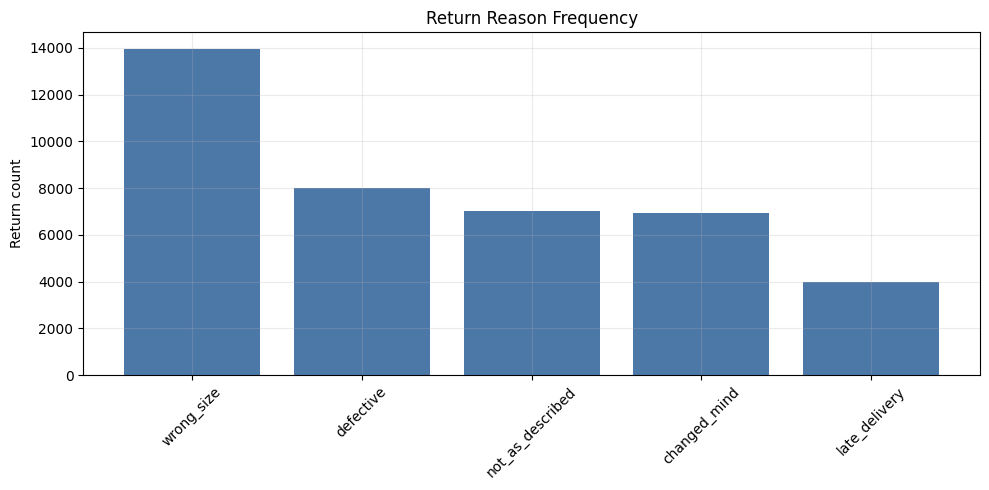

In [6]:
reason_summary = pd.DataFrame()
if reason_items.empty or 'return_reason_std' not in reason_items.columns:
    print('Return reason analysis cannot be computed because return reason data is unavailable.')
else:
    reason_summary = reason_items.groupby('return_reason_std').agg(
        return_count=('return_reason_std', 'count'),
        returned_quantity=('returned_quantity_std', 'sum'),
        refund_amount=('refund_amount_std', 'sum'),
    ).reset_index()
    reason_summary['return_share'] = reason_summary['return_count'] / reason_summary['return_count'].sum()
    reason_summary['average_refund_amount'] = reason_summary['refund_amount'] / reason_summary['return_count'].replace(0, np.nan)
    reason_summary = reason_summary.sort_values('return_count', ascending=False)
    display(reason_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(reason_summary['return_reason_std'].astype(str), reason_summary['return_count'], color='#4C78A8')
    ax.set_title('Return Reason Frequency')
    ax.set_ylabel('Return count')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 7. Return Reason by Category

Create a category-by-return-reason table and a heatmap-style chart using counts and within-category reason share.

,category_final,return_reason_std,return_count,returned_quantity,refund_amount,category_reason_share
4,Casual,wrong_size,454,1243,"4,957,854.0000",0.3509
1,Casual,defective,262,725,"2,875,267.7000",0.2025
3,Casual,not_as_described,229,571,"2,274,630.5200",0.1770
0,Casual,changed_mind,228,619,"2,525,235.9700",0.1762
2,Casual,late_delivery,121,341,"1,394,106.1800",0.0935
9,GenZ,wrong_size,734,2099,"4,020,617.3800",0.3449
6,GenZ,defective,429,1170,"2,176,143.3500",0.2016
8,GenZ,not_as_described,376,1033,"2,040,196.6600",0.1767
5,GenZ,changed_mind,349,928,"1,742,880.7700",0.1640
7,GenZ,late_delivery,240,643,"1,169,932.0800",0.1128


return_reason_std,changed_mind,defective,late_delivery,not_as_described,wrong_size
category_final,,,,,
Casual,0.1762,0.2025,0.0935,0.1770,0.3509
GenZ,0.1640,0.2016,0.1128,0.1767,0.3449
Outdoor,0.1715,0.2037,0.0996,0.1751,0.3501
Streetwear,0.1757,0.1986,0.0990,0.1768,0.3499


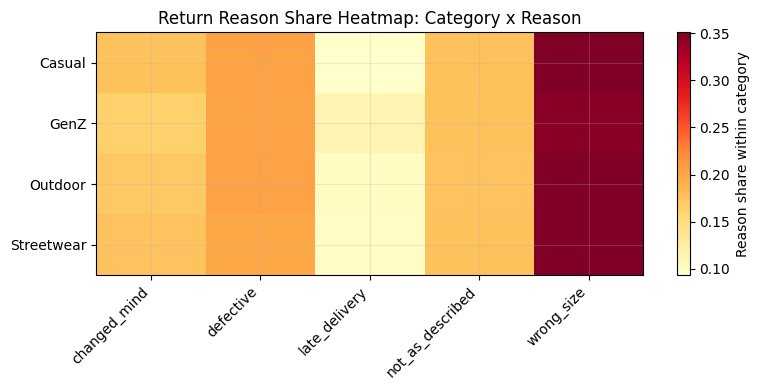

In [7]:
category_reason = pd.DataFrame()
heatmap_matrix = pd.DataFrame()
if reason_items.empty or 'category_final' not in reason_items.columns:
    print('Category by return reason analysis cannot be computed.')
else:
    category_reason = reason_items.groupby(['category_final', 'return_reason_std']).agg(
        return_count=('return_reason_std', 'count'),
        returned_quantity=('returned_quantity_std', 'sum'),
        refund_amount=('refund_amount_std', 'sum'),
    ).reset_index()
    category_reason['category_reason_share'] = category_reason['return_count'] / category_reason.groupby('category_final')['return_count'].transform('sum').replace(0, np.nan)
    display(category_reason.sort_values(['category_final', 'return_count'], ascending=[True, False]))

    top_categories = reason_items['category_final'].value_counts().head(8).index.tolist()
    top_reasons = reason_summary.head(8)['return_reason_std'].tolist() if not reason_summary.empty else reason_items['return_reason_std'].value_counts().head(8).index.tolist()
    heatmap_matrix = category_reason[category_reason['category_final'].isin(top_categories) & category_reason['return_reason_std'].isin(top_reasons)].pivot(index='category_final', columns='return_reason_std', values='category_reason_share').fillna(0)
    display(heatmap_matrix)

    fig, ax = plt.subplots(figsize=(max(8, heatmap_matrix.shape[1] * 1.0), max(4, heatmap_matrix.shape[0] * 0.5)))
    im = ax.imshow(heatmap_matrix.values, aspect='auto', cmap='YlOrRd')
    ax.set_title('Return Reason Share Heatmap: Category x Reason')
    ax.set_xticks(np.arange(heatmap_matrix.shape[1]))
    ax.set_xticklabels(heatmap_matrix.columns, rotation=45, ha='right')
    ax.set_yticks(np.arange(heatmap_matrix.shape[0]))
    ax.set_yticklabels(heatmap_matrix.index)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Reason share within category')
    plt.tight_layout()
    plt.show()

## 8. Wrong-Size Concentration Analysis

Group wrong-size-like labels explicitly, then analyze concentration by size, category, and category-size combinations.

Wrong-size-like labels grouped together:
['wrong_size']


,size_final,total_returns,wrong_size_return_count,wrong_size_return_share
1,M,9824,3486,0.3548
0,L,9741,3401,0.3491
3,XL,10655,3711,0.3483
2,S,9723,3372,0.3468


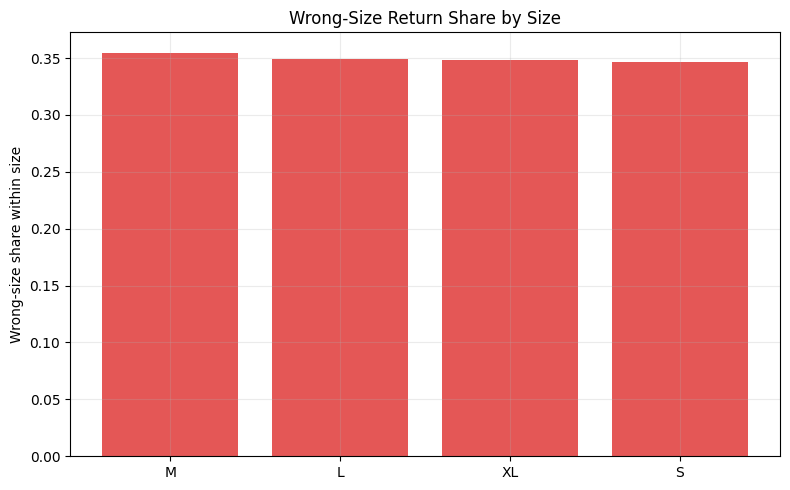

,category_final,total_returns,wrong_size_return_count,wrong_size_return_share
0,Casual,1294,454,0.3509
2,Outdoor,14720,5154,0.3501
3,Streetwear,21801,7628,0.3499
1,GenZ,2128,734,0.3449


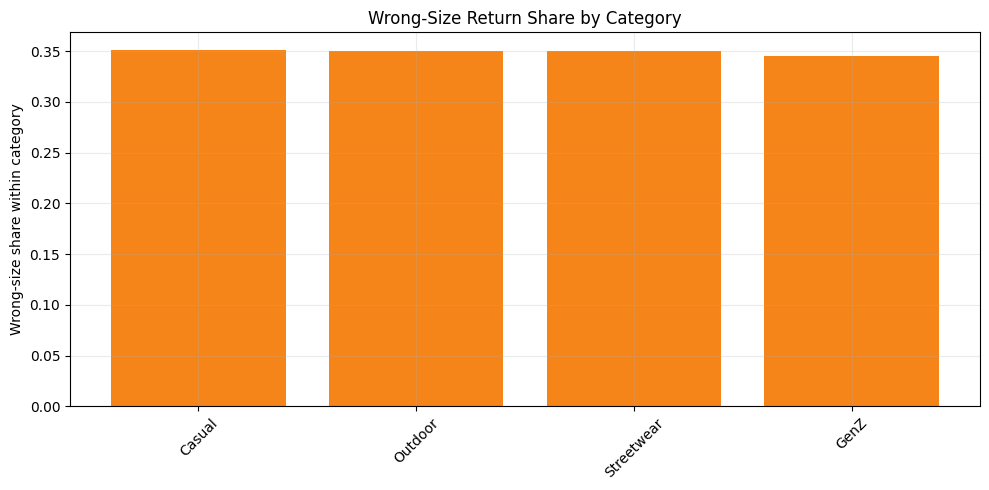

size_final,L,M,S,XL
category_final,,,,
Casual,0.3512,0.3607,0.3473,0.3404
GenZ,0.3377,0.3773,0.3136,0.3664
Outdoor,0.3560,0.3478,0.3500,0.3459
Streetwear,0.3445,0.3573,0.3494,0.3489


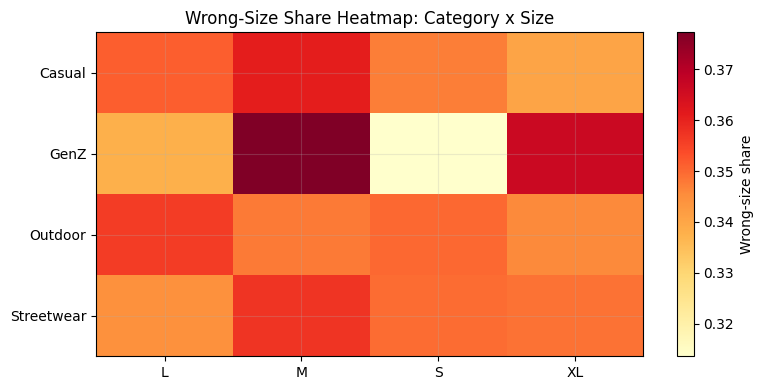

In [8]:
wrong_size_labels = []
wrong_size_records = pd.DataFrame()
wrong_size_by_size = pd.DataFrame()
wrong_size_by_category = pd.DataFrame()
wrong_size_cat_size = pd.DataFrame()

def is_wrong_size_reason(reason):
    if pd.isna(reason):
        return False
    reason = str(reason)
    patterns = ['wrong_size', 'size_issue', 'too_small', 'too_large', 'fit_issue']
    return any(p in reason for p in patterns)

if reason_items.empty or 'return_reason_std' not in reason_items.columns:
    print('Wrong-size analysis cannot be computed because return reasons are unavailable.')
else:
    wrong_size_labels = sorted([r for r in reason_items['return_reason_std'].dropna().unique() if is_wrong_size_reason(r)])
    print('Wrong-size-like labels grouped together:')
    print(wrong_size_labels if wrong_size_labels else 'None found')
    reason_items['is_wrong_size_reason'] = reason_items['return_reason_std'].map(is_wrong_size_reason)
    wrong_size_records = reason_items[reason_items['is_wrong_size_reason']].copy()

    if not wrong_size_records.empty and 'size_final' in reason_items.columns and reason_items['size_final'].notna().sum() > 0:
        wrong_size_by_size = reason_items.groupby('size_final').agg(
            total_returns=('return_reason_std', 'count'),
            wrong_size_return_count=('is_wrong_size_reason', 'sum'),
        ).reset_index()
        wrong_size_by_size['wrong_size_return_share'] = wrong_size_by_size['wrong_size_return_count'] / wrong_size_by_size['total_returns'].replace(0, np.nan)
        wrong_size_by_size = wrong_size_by_size.sort_values('wrong_size_return_share', ascending=False)
        display(wrong_size_by_size)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(wrong_size_by_size['size_final'].astype(str), wrong_size_by_size['wrong_size_return_share'], color='#E45756')
        ax.set_title('Wrong-Size Return Share by Size')
        ax.set_ylabel('Wrong-size share within size')
        plt.tight_layout()
        plt.show()
    else:
        print('Size is unavailable or wrong-size records are absent; wrong-size-by-size analysis is skipped.')

    wrong_size_by_category = reason_items.groupby('category_final').agg(
        total_returns=('return_reason_std', 'count'),
        wrong_size_return_count=('is_wrong_size_reason', 'sum'),
    ).reset_index()
    wrong_size_by_category['wrong_size_return_share'] = wrong_size_by_category['wrong_size_return_count'] / wrong_size_by_category['total_returns'].replace(0, np.nan)
    wrong_size_by_category = wrong_size_by_category.sort_values('wrong_size_return_share', ascending=False)
    display(wrong_size_by_category)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(wrong_size_by_category['category_final'].astype(str), wrong_size_by_category['wrong_size_return_share'], color='#F58518')
    ax.set_title('Wrong-Size Return Share by Category')
    ax.set_ylabel('Wrong-size share within category')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    if 'size_final' in reason_items.columns and reason_items['size_final'].notna().sum() > 0:
        wrong_size_cat_size = reason_items.groupby(['category_final', 'size_final']).agg(
            total_returns=('return_reason_std', 'count'),
            wrong_size_return_count=('is_wrong_size_reason', 'sum'),
        ).reset_index()
        wrong_size_cat_size['wrong_size_return_share'] = wrong_size_cat_size['wrong_size_return_count'] / wrong_size_cat_size['total_returns'].replace(0, np.nan)
        top_categories = wrong_size_by_category.head(6)['category_final'].tolist()
        top_sizes = wrong_size_by_size.head(6)['size_final'].tolist() if not wrong_size_by_size.empty else reason_items['size_final'].value_counts().head(6).index.tolist()
        ws_matrix = wrong_size_cat_size[wrong_size_cat_size['category_final'].isin(top_categories) & wrong_size_cat_size['size_final'].isin(top_sizes)].pivot(index='category_final', columns='size_final', values='wrong_size_return_share').fillna(0)
        display(ws_matrix)
        fig, ax = plt.subplots(figsize=(max(8, ws_matrix.shape[1] * 0.9), max(4, ws_matrix.shape[0] * 0.5)))
        im = ax.imshow(ws_matrix.values, aspect='auto', cmap='YlOrRd')
        ax.set_title('Wrong-Size Share Heatmap: Category x Size')
        ax.set_xticks(np.arange(ws_matrix.shape[1]))
        ax.set_xticklabels(ws_matrix.columns)
        ax.set_yticks(np.arange(ws_matrix.shape[0]))
        ax.set_yticklabels(ws_matrix.index)
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Wrong-size share')
        plt.tight_layout()
        plt.show()

## 9. Defective/Damaged Return Analysis

Group defective-like labels explicitly, then analyze concentration by category and segment.

Defective-like labels grouped together:
['defective']


,category_final,total_returns,defective_return_count,defective_return_share
2,Outdoor,14720,2999,0.2037
0,Casual,1294,262,0.2025
1,GenZ,2128,429,0.2016
3,Streetwear,21801,4330,0.1986


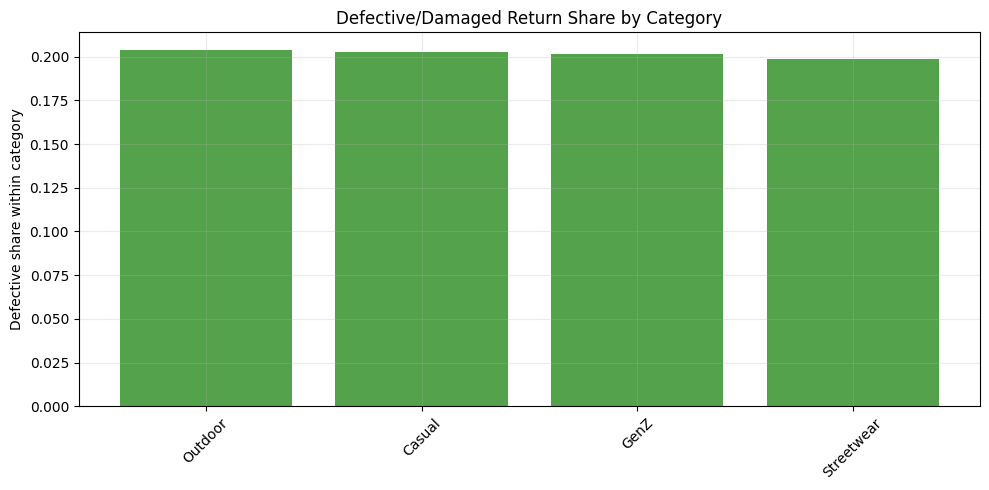

,segment_final,total_returns,defective_return_count,defective_return_share
0,Activewear,13085,2675,0.2044
2,Balanced,5613,1143,0.2036
7,Trendy,2128,429,0.2016
5,Premium,1722,346,0.2009
3,Everyday,10143,2030,0.2001
1,All-weather,1207,240,0.1988
4,Performance,5444,1055,0.1938
6,Standard,601,102,0.1697


In [9]:
defective_labels = []
defective_by_category = pd.DataFrame()
defective_by_segment = pd.DataFrame()

def is_defective_reason(reason):
    if pd.isna(reason):
        return False
    reason = str(reason)
    patterns = ['defective', 'damaged', 'broken', 'quality_issue', 'faulty']
    return any(p in reason for p in patterns)

if reason_items.empty or 'return_reason_std' not in reason_items.columns:
    print('Defective/damaged analysis cannot be computed because return reasons are unavailable.')
else:
    defective_labels = sorted([r for r in reason_items['return_reason_std'].dropna().unique() if is_defective_reason(r)])
    print('Defective-like labels grouped together:')
    print(defective_labels if defective_labels else 'None found')
    reason_items['is_defective_reason'] = reason_items['return_reason_std'].map(is_defective_reason)

    defective_by_category = reason_items.groupby('category_final').agg(
        total_returns=('return_reason_std', 'count'),
        defective_return_count=('is_defective_reason', 'sum'),
    ).reset_index()
    defective_by_category['defective_return_share'] = defective_by_category['defective_return_count'] / defective_by_category['total_returns'].replace(0, np.nan)
    defective_by_category = defective_by_category.sort_values('defective_return_share', ascending=False)
    display(defective_by_category)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(defective_by_category['category_final'].astype(str), defective_by_category['defective_return_share'], color='#54A24B')
    ax.set_title('Defective/Damaged Return Share by Category')
    ax.set_ylabel('Defective share within category')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    if 'segment_final' in reason_items.columns and reason_items['segment_final'].notna().sum() > 0:
        defective_by_segment = reason_items.dropna(subset=['segment_final']).groupby('segment_final').agg(
            total_returns=('return_reason_std', 'count'),
            defective_return_count=('is_defective_reason', 'sum'),
        ).reset_index()
        defective_by_segment['defective_return_share'] = defective_by_segment['defective_return_count'] / defective_by_segment['total_returns'].replace(0, np.nan)
        defective_by_segment = defective_by_segment.sort_values('defective_return_share', ascending=False)
        display(defective_by_segment)

## 10. Return Reason Trend Over Time

Aggregate return reasons by month and plot the trend for the top reasons.

,year_month,return_reason_std,return_count,returned_quantity,month_start
0,2012-07,changed_mind,22,64,2012-07-01
1,2012-07,defective,27,69,2012-07-01
2,2012-07,late_delivery,9,34,2012-07-01
3,2012-07,not_as_described,15,46,2012-07-01
4,2012-07,wrong_size,34,81,2012-07-01
5,2012-08,changed_mind,62,166,2012-08-01
6,2012-08,defective,90,217,2012-08-01
7,2012-08,late_delivery,38,85,2012-08-01
8,2012-08,not_as_described,63,209,2012-08-01
9,2012-08,wrong_size,140,367,2012-08-01


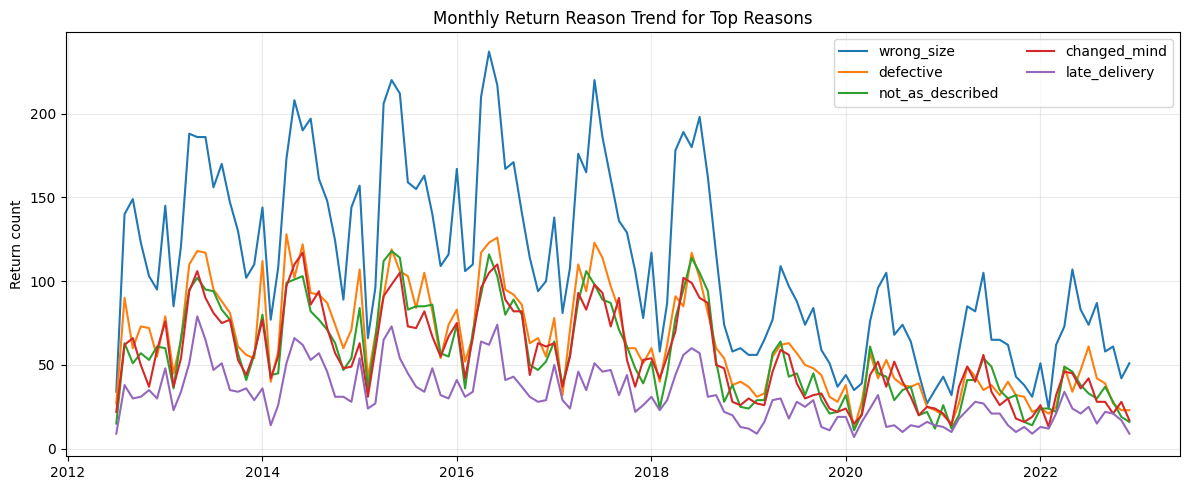

return_reason_std,changed_mind,defective,late_delivery,not_as_described,wrong_size
month_start,,,,,
2021-01-01,0.1707,0.1626,0.1057,0.2114,0.3496
2021-02-01,0.1687,0.1807,0.1205,0.1446,0.3855
2021-03-01,0.2313,0.1688,0.1125,0.1250,0.3625
2021-04-01,0.1984,0.1984,0.0931,0.1660,0.3441
2021-05-01,0.1709,0.1838,0.1197,0.1752,0.3504
2021-06-01,0.2022,0.1264,0.0975,0.1949,0.3791
2021-07-01,0.1643,0.1836,0.1014,0.2367,0.3140
2021-08-01,0.1453,0.1788,0.1173,0.1955,0.3631
2021-09-01,0.1705,0.2273,0.0795,0.1705,0.3523


In [10]:
reason_monthly = pd.DataFrame()
if reason_items.empty or 'return_date_std' not in reason_items.columns or pd.Series(reason_items['return_date_std']).isna().all():
    print('Return dates are unavailable; return reason trend analysis is skipped.')
else:
    temp = reason_items.dropna(subset=['return_date_std']).copy()
    temp['year_month'] = temp['return_date_std'].dt.to_period('M').astype('string')
    reason_monthly = temp.groupby(['year_month', 'return_reason_std']).agg(
        return_count=('return_reason_std', 'count'),
        returned_quantity=('returned_quantity_std', 'sum'),
    ).reset_index()
    reason_monthly['month_start'] = pd.PeriodIndex(reason_monthly['year_month'], freq='M').to_timestamp()
    display(reason_monthly.head(20))

    top_reasons = reason_summary.head(5)['return_reason_std'].tolist() if not reason_summary.empty else temp['return_reason_std'].value_counts().head(5).index.tolist()
    fig, ax = plt.subplots(figsize=(12, 5))
    for reason in top_reasons:
        sub = reason_monthly[reason_monthly['return_reason_std'] == reason].sort_values('month_start')
        ax.plot(sub['month_start'], sub['return_count'], label=reason)
    ax.set_title('Monthly Return Reason Trend for Top Reasons')
    ax.set_ylabel('Return count')
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    reason_mix = reason_monthly.pivot(index='month_start', columns='return_reason_std', values='return_count').fillna(0)
    reason_mix = reason_mix.div(reason_mix.sum(axis=1).replace(0, np.nan), axis=0)
    display(reason_mix.tail(24))

## 11. Business Recommendation Insights

Convert the observed return-reason patterns into practical recommendations, with each recommendation tied to measured evidence.

In [11]:
recommendations = []
if not wrong_size_by_category.empty:
    top_ws_cat = wrong_size_by_category.head(3)
    for row in top_ws_cat.itertuples():
        recommendations.append({
            'recommendation': 'Improve sizing guides, fit notes, and size-specific product education.',
            'evidence': f"{row.category_final} wrong-size share is {row.wrong_size_return_share:.2%} across {int(row.total_returns)} returns.",
        })
if not defective_by_category.empty:
    top_def_cat = defective_by_category.head(3)
    for row in top_def_cat.itertuples():
        if row.defective_return_count > 0:
            recommendations.append({
                'recommendation': 'Review quality control, supplier consistency, and inbound inspection.',
                'evidence': f"{row.category_final} defective/damaged share is {row.defective_return_share:.2%} across {int(row.total_returns)} returns.",
            })
if not reason_summary.empty:
    for row in reason_summary.head(5).itertuples():
        if row.return_reason_std in ['not_as_described']:
            recommendations.append({
                'recommendation': 'Improve product descriptions, photography, and expectation-setting content.',
                'evidence': f"{row.return_reason_std} accounts for {row.return_share:.2%} of returns.",
            })
        if row.return_reason_std in ['wrong_item', 'late_delivery']:
            recommendations.append({
                'recommendation': 'Review fulfillment accuracy and logistics performance.',
                'evidence': f"{row.return_reason_std} accounts for {row.return_share:.2%} of returns.",
            })

recommendations_df = pd.DataFrame(recommendations).drop_duplicates() if recommendations else pd.DataFrame(columns=['recommendation', 'evidence'])
display(recommendations_df)

,recommendation,evidence
0,"Improve sizing guides, fit notes, and size-spe...",Casual wrong-size share is 35.09% across 1294 ...
1,"Improve sizing guides, fit notes, and size-spe...",Outdoor wrong-size share is 35.01% across 1472...
2,"Improve sizing guides, fit notes, and size-spe...",Streetwear wrong-size share is 34.99% across 2...
3,"Review quality control, supplier consistency, ...",Outdoor defective/damaged share is 20.37% acro...
4,"Review quality control, supplier consistency, ...",Casual defective/damaged share is 20.25% acros...
5,"Review quality control, supplier consistency, ...",GenZ defective/damaged share is 20.16% across ...
6,"Improve product descriptions, photography, and...",not_as_described accounts for 17.62% of returns.
7,Review fulfillment accuracy and logistics perf...,late_delivery accounts for 9.98% of returns.


## 12. Leakage-Safe Return-Reason Feature Preview

Create historical aggregate reason features only. Future return reasons are not used directly for forecasting.

In [12]:
feature_preview = pd.DataFrame()
feature_registry = pd.DataFrame()
if reason_items.empty or 'return_date_std' not in reason_items.columns or pd.Series(reason_items['return_date_std']).isna().all():
    print('Return-date-based reason features cannot be built because return dates are unavailable.')
else:
    temp = reason_items.dropna(subset=['return_date_std']).copy()
    temp['date'] = temp['return_date_std']
    daily_reason = temp.groupby('date').agg(
        total_returns=('return_reason_std', 'count'),
        wrong_size_return_count=('is_wrong_size_reason', 'sum') if 'is_wrong_size_reason' in temp.columns else ('return_reason_std', lambda s: 0),
        defective_return_count=('is_defective_reason', 'sum') if 'is_defective_reason' in temp.columns else ('return_reason_std', lambda s: 0),
    ).reset_index()
    daily_reason['wrong_size_return_ratio'] = daily_reason['wrong_size_return_count'] / daily_reason['total_returns'].replace(0, np.nan)
    daily_reason['defective_return_ratio'] = daily_reason['defective_return_count'] / daily_reason['total_returns'].replace(0, np.nan)
    if 'return_reason_std' in temp.columns:
        mix_parts = []
        top_reasons = reason_summary.head(3)['return_reason_std'].tolist() if not reason_summary.empty else temp['return_reason_std'].value_counts().head(3).index.tolist()
        for reason in top_reasons:
            col = f'reason_mix_{reason}'
            part = temp.assign(is_reason=(temp['return_reason_std'] == reason).astype(int)).groupby('date')['is_reason'].mean().rename(col)
            mix_parts.append(part)
        if mix_parts:
            mix_df = pd.concat(mix_parts, axis=1).reset_index()
            daily_reason = daily_reason.merge(mix_df, on='date', how='left')

    feature_preview = daily_reason.sort_values('date').copy()
    feature_preview['wrong_size_return_ratio_lag'] = feature_preview['wrong_size_return_ratio'].shift(30)
    feature_preview['defective_return_ratio_lag'] = feature_preview['defective_return_ratio'].shift(30)
    feature_preview['wrong_size_return_ratio_roll_mean_30'] = feature_preview['wrong_size_return_ratio'].shift(1).rolling(30, min_periods=7).mean()
    feature_preview['defective_return_ratio_roll_mean_30'] = feature_preview['defective_return_ratio'].shift(1).rolling(30, min_periods=7).mean()
    reason_mix_cols = [c for c in feature_preview.columns if c.startswith('reason_mix_')]
    for c in reason_mix_cols:
        feature_preview[f'{c}_lag'] = feature_preview[c].shift(30)

    preview_cols = ['date', 'total_returns', 'wrong_size_return_count', 'defective_return_count', 'wrong_size_return_ratio', 'defective_return_ratio', 'wrong_size_return_ratio_lag', 'defective_return_ratio_lag', 'wrong_size_return_ratio_roll_mean_30', 'defective_return_ratio_roll_mean_30']
    preview_cols += [c for c in feature_preview.columns if c.startswith('reason_mix_') and c.endswith('_lag')]
    display(feature_preview[preview_cols].head(40))

    same_day_known_only = ['wrong_size_return_ratio', 'defective_return_ratio']
    historical_safe = [c for c in feature_preview.columns if c.endswith('_lag') or c.endswith('_mean_30')]
    feature_registry = pd.DataFrame({
        'feature': same_day_known_only + historical_safe,
        'feature_type': ['requires known current-day return reasons'] * len(same_day_known_only) + ['historical lagged/rolling only'] * len(historical_safe),
        'forecast_use_note': ['Use only if return reasons are genuinely known before prediction.'] * len(same_day_known_only) + ['Leakage-safe because the feature uses only prior realized return-reason history.'] * len(historical_safe),
    })
    display(feature_registry)

,date,total_returns,wrong_size_return_count,defective_return_count,wrong_size_return_ratio,defective_return_ratio,wrong_size_return_ratio_lag,defective_return_ratio_lag,wrong_size_return_ratio_roll_mean_30,defective_return_ratio_roll_mean_30,reason_mix_wrong_size_lag,reason_mix_defective_lag,reason_mix_not_as_described_lag
0,2012-07-11,1,1,0,1.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-12,1,0,0,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-14,2,1,0,0.5000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-15,2,0,0,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-16,3,3,0,1.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2012-07-17,3,0,2,0.0000,0.6667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2012-07-18,2,0,0,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2012-07-19,5,2,1,0.4000,0.2000,NaN,NaN,0.3571,0.0952,NaN,NaN,NaN
8,2012-07-20,1,1,0,1.0000,0.0000,NaN,NaN,0.3625,0.1083,NaN,NaN,NaN
9,2012-07-21,4,1,0,0.2500,0.0000,NaN,NaN,0.4333,0.0963,NaN,NaN,NaN


,feature,feature_type,forecast_use_note
0,wrong_size_return_ratio,requires known current-day return reasons,Use only if return reasons are genuinely known...
1,defective_return_ratio,requires known current-day return reasons,Use only if return reasons are genuinely known...
2,wrong_size_return_ratio_lag,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
3,defective_return_ratio_lag,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
4,wrong_size_return_ratio_roll_mean_30,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
5,defective_return_ratio_roll_mean_30,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
6,reason_mix_wrong_size_lag,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
7,reason_mix_defective_lag,historical lagged/rolling only,Leakage-safe because the feature uses only pri...
8,reason_mix_not_as_described_lag,historical lagged/rolling only,Leakage-safe because the feature uses only pri...


## 13. Key Observations and Warnings

Final concise summary with top return reasons, wrong-size concentration, defective concentration, trend notes, recommendations, and leakage-safe features.

In [13]:
summary_lines = []

if not reason_summary.empty:
    top_reasons = reason_summary.head(5)
    summary_lines.append('Most common return reasons: ' + ', '.join(f"{r.return_reason_std} ({r.return_share:.2%})" for r in top_reasons.itertuples()))
else:
    summary_lines.append('Return reasons could not be summarized because the reason field was unavailable.')

if not category_reason.empty:
    notable = category_reason.sort_values('category_reason_share', ascending=False).head(5)
    summary_lines.append('Categories associated with specific return reasons: ' + ', '.join(f"{r.category_final}/{r.return_reason_std} ({r.category_reason_share:.2%})" for r in notable.itertuples()))

if not wrong_size_by_category.empty:
    top_ws_cat = wrong_size_by_category.head(5)
    summary_lines.append('Wrong-size returns concentrate by category in: ' + ', '.join(f"{r.category_final} ({r.wrong_size_return_share:.2%})" for r in top_ws_cat.itertuples()))
if not wrong_size_by_size.empty:
    top_ws_size = wrong_size_by_size.head(5)
    summary_lines.append('Wrong-size returns concentrate by size in: ' + ', '.join(f"{r.size_final} ({r.wrong_size_return_share:.2%})" for r in top_ws_size.itertuples()))

if not defective_by_category.empty:
    top_def = defective_by_category.head(5)
    summary_lines.append('Defective/damaged returns concentrate in: ' + ', '.join(f"{r.category_final} ({r.defective_return_share:.2%})" for r in top_def.itertuples()))

if not reason_monthly.empty:
    top_recent = reason_monthly.groupby('return_reason_std')['return_count'].sum().sort_values(ascending=False).head(3).index.tolist()
    summary_lines.append('Return reason mix changes over time should be reviewed especially for: ' + ', '.join(top_recent))
else:
    summary_lines.append('Return reason trend over time could not be evaluated because return dates were unavailable.')

if not recommendations_df.empty:
    summary_lines.append('Practical business recommendations: ' + ' | '.join(f"{r.recommendation} Evidence: {r.evidence}" for r in recommendations_df.head(5).itertuples()))

if reason_warnings:
    summary_lines.append('Return reason data quality warnings: ' + '; '.join(reason_warnings))
else:
    summary_lines.append('Return reason data quality warnings: none beyond the checks reported in the notebook tables.')

summary_lines.append('Recommended leakage-safe return-reason aggregate features: wrong_size_return_ratio_lag, defective_return_ratio_lag, return_reason_mix_lag, wrong_size_return_ratio_roll_mean_30, and defective_return_ratio_roll_mean_30.')
summary_lines.append('Future return reasons must not be used directly for forecasting unless they are genuinely known before prediction.')
summary_lines.append('Causal caution: this is observational EDA. Return reasons can vary with product design, sizing, quality, fulfillment, seasonality, and customer mix.')

print('KEY OBSERVATIONS AND WARNINGS')
for line in summary_lines:
    print('-', line)

KEY OBSERVATIONS AND WARNINGS
- Most common return reasons: wrong_size (34.97%), defective (20.08%), not_as_described (17.62%), changed_mind (17.35%), late_delivery (9.98%)
- Categories associated with specific return reasons: Casual/wrong_size (35.09%), Outdoor/wrong_size (35.01%), Streetwear/wrong_size (34.99%), GenZ/wrong_size (34.49%), Outdoor/defective (20.37%)
- Wrong-size returns concentrate by category in: Casual (35.09%), Outdoor (35.01%), Streetwear (34.99%), GenZ (34.49%)
- Wrong-size returns concentrate by size in: M (35.48%), L (34.91%), XL (34.83%), S (34.68%)
- Defective/damaged returns concentrate in: Outdoor (20.37%), Casual (20.25%), GenZ (20.16%), Streetwear (19.86%)
- Return reason mix changes over time should be reviewed especially for: wrong_size, defective, not_as_described
- Practical business recommendations: Improve sizing guides, fit notes, and size-specific product education. Evidence: Casual wrong-size share is 35.09% across 1294 returns. | Improve sizing g